# 🧠 Brain Tumor Detection & Classification
### Using EfficientNetB0 Transfer Learning + Fine-Tuning
**Dataset:** Brain Tumor MRI Dataset (Masoud Nickparvar)

**Classes:** Glioma | Meningioma | No Tumor | Pituitary

In [1]:
# --- Cell 1: Install Dependencies
!pip install tensorflow keras numpy matplotlib scikit-learn opencv-python kaggle seaborn -q


In [2]:
# --- Cell 2: Import All Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# --- Cell 3: Enter Kaggle Credentials
import getpass, json as _json

kaggle_username = input("Enter your Kaggle username: ")
kaggle_key = getpass.getpass("Enter your Kaggle API key: ")

# Create kaggle.json from entered credentials
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
kaggle_creds = {"username": kaggle_username, "key": kaggle_key}
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    _json.dump(kaggle_creds, f)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle credentials saved successfully!")


Enter your Kaggle username: sruthiragyari
Enter your Kaggle API key: ··········
Kaggle credentials saved successfully!


In [4]:
# --- Cell 4: Download Dataset via Kaggle API
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -p /content/dataset


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 218MB/s]



In [5]:
# --- Cell 5: Verify Folder Structure
print("Dataset folder structure:")
for root, dirs, files_list in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level >= 2:
        break


Dataset folder structure:
dataset/
  Training/
    meningioma/


In [6]:
# --- Cell 6: Set Dataset Paths and Verify
TRAIN_DIR = '/content/dataset/Training'
TEST_DIR = '/content/dataset/Testing'

# Handle edge case where dataset extracts into a subfolder
if not os.path.exists(TRAIN_DIR):
    subdirs = os.listdir('/content/dataset')
    for sd in subdirs:
        candidate = os.path.join('/content/dataset', sd, 'Training')
        if os.path.exists(candidate):
            TRAIN_DIR = candidate
            TEST_DIR = os.path.join('/content/dataset', sd, 'Testing')
            print(f"Found dataset in subfolder: {sd}")
            break

print("Training classes:", sorted(os.listdir(TRAIN_DIR)))
print("Testing classes:", sorted(os.listdir(TEST_DIR)))
assert len(os.listdir(TRAIN_DIR)) >= 4, "Expected 4 training class folders!"
assert len(os.listdir(TEST_DIR)) >= 4, "Expected 4 testing class folders!"
print("✅ Dataset structure verified!")


Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
✅ Dataset structure verified!


In [7]:
# --- Cell 7: Count Images Per Class
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("TRAINING SET:")
train_counts = {}
for cls in classes:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    train_counts[cls] = count
    print(f"  {cls}: {count} images")

print("\nTESTING SET:")
test_counts = {}
for cls in classes:
    count = len(os.listdir(os.path.join(TEST_DIR, cls)))
    test_counts[cls] = count
    print(f"  {cls}: {count} images")

print(f"\nTotal Training: {sum(train_counts.values())}")
print(f"Total Testing: {sum(test_counts.values())}")


TRAINING SET:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

TESTING SET:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images

Total Training: 5600
Total Testing: 1600


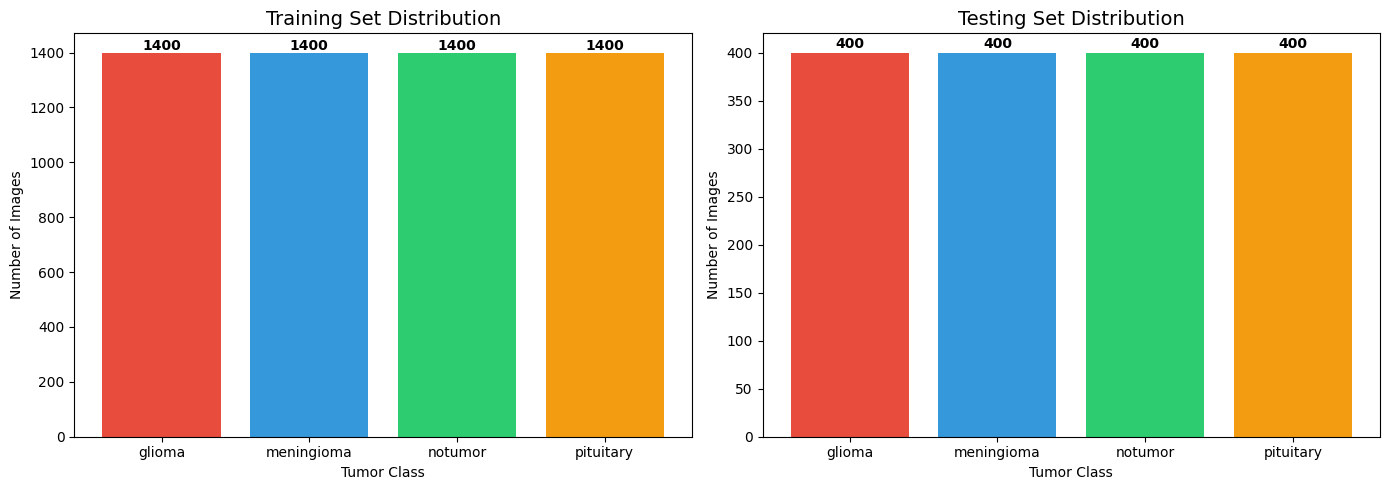

In [8]:
# --- Cell 8: Plot Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
axes[0].bar(train_counts.keys(), train_counts.values(), color=colors)
axes[0].set_title('Training Set Distribution', fontsize=14)
axes[0].set_xlabel('Tumor Class')
axes[0].set_ylabel('Number of Images')
for i, (k, v) in enumerate(train_counts.items()):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].bar(test_counts.keys(), test_counts.values(), color=colors)
axes[1].set_title('Testing Set Distribution', fontsize=14)
axes[1].set_xlabel('Tumor Class')
axes[1].set_ylabel('Number of Images')
for i, (k, v) in enumerate(test_counts.items()):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


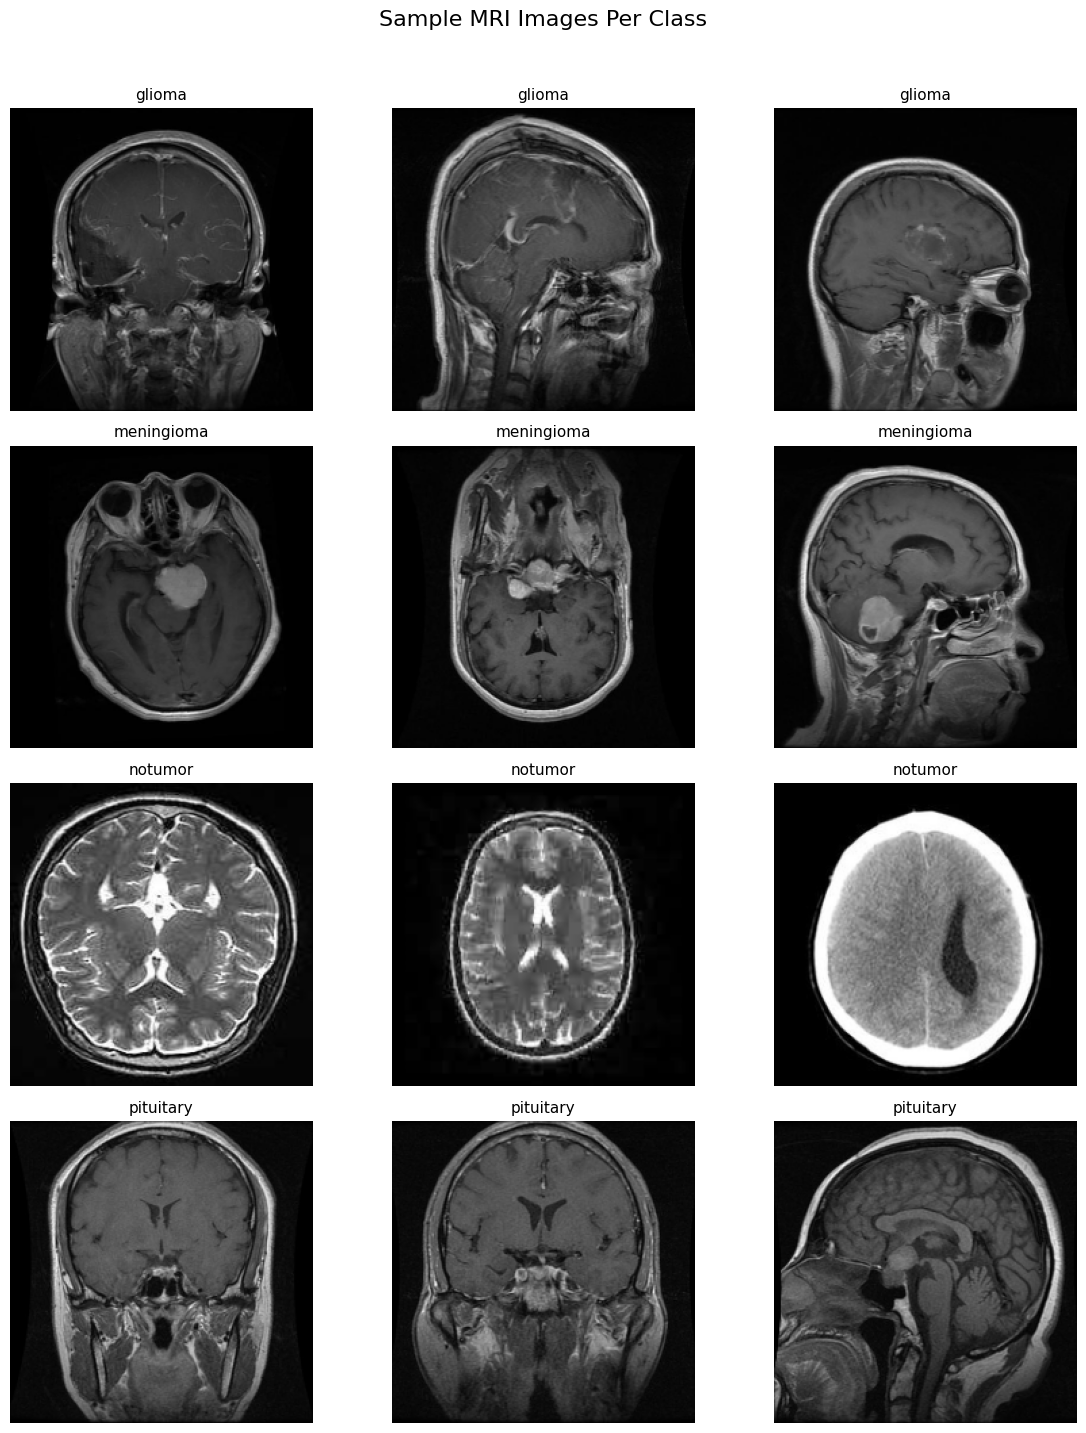

In [9]:
# --- Cell 9: Display Sample MRI Images (4x3 Grid)
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for row, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = sorted(os.listdir(cls_path))[:3]
    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        axes[row][col].imshow(img)
        axes[row][col].set_title(f'{cls}', fontsize=11)
        axes[row][col].axis('off')

plt.suptitle('Sample MRI Images Per Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# --- Cell 10: Set Constants
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
SEED = 42


In [11]:
# --- Cell 11: Create Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print(f"Training batches: {len(train_generator)} ({train_generator.samples} images)")
print(f"Validation batches: {len(val_generator)} ({val_generator.samples} images)")
print(f"Test batches: {len(test_generator)} ({test_generator.samples} images)")


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training batches: 140 (4480 images)
Validation batches: 35 (1120 images)
Test batches: 50 (1600 images)


In [12]:
# --- Cell 12: Build Model — Phase 1 (Feature Extraction)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,679 (16.73 MB)

 Trainable params: 332,036 (1.27 MB)

 Non-trainable params: 4,052,643 (15.46 MB)


Total parameters: 4,384,679
Trainable parameters: 332,036


In [13]:
# --- Cell 13: Define Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)


In [14]:
# --- Cell 14: Train — Phase 1 (Top Layers Only)
print("=" * 50)
print("PHASE 1: Training top layers only")
print("=" * 50)

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

phase1_val_acc = max(history_phase1.history['val_accuracy'])
print(f"\n✅ Phase 1 best validation accuracy: {phase1_val_acc:.4f}")


PHASE 1: Training top layers only
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.2624 - loss: 1.9464
Epoch 1: val_accuracy improved from None to 0.25000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 107s 515ms/step - accuracy: 0.2830 - loss: 1.7677 - val_accuracy: 0.2500 - val_loss: 1.3925 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.3198 - loss: 1.5427
Epoch 2: val_accuracy improved from 0.25000 to 0.41786, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 453ms/step - accuracy: 0.3221 - loss: 1.5304 - val_accuracy: 0.4179 - val_loss: 1.3607 - learning_rate: 0.0010
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.3439 - loss: 1.4837
Epoch 3: val_accuracy did not improve from 0.41786
140/140 ━━━━━━━━━━━━━━━━━━━━ 61s 438ms/step - accuracy: 0.3446 - loss: 1.4685 - val

In [15]:
# --- Cell 15: Fine-Tune — Phase 2 (Unfreeze Last 30 Layers)
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Trainable layers after unfreezing last 30: {sum(1 for l in base_model.layers if l.trainable)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\n" + "=" * 50)
print("PHASE 2: Fine-tuning last 30 layers")
print("=" * 50)

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping_ft, reduce_lr, checkpoint],
    verbose=1
)

phase2_val_acc = max(history_phase2.history['val_accuracy'])
print(f"\n✅ Phase 2 best validation accuracy: {phase2_val_acc:.4f}")


Total layers in base model: 238
Trainable layers after unfreezing last 30: 30

PHASE 2: Fine-tuning last 30 layers
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.2666 - loss: 1.7702
Epoch 1: val_accuracy did not improve from 0.41786
140/140 ━━━━━━━━━━━━━━━━━━━━ 101s 487ms/step - accuracy: 0.2766 - loss: 1.7050 - val_accuracy: 0.2723 - val_loss: 1.4869 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.2671 - loss: 1.6383
Epoch 2: val_accuracy did not improve from 0.41786
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 444ms/step - accuracy: 0.2772 - loss: 1.6182 - val_accuracy: 0.3054 - val_loss: 1.4285 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.3118 - loss: 1.5446
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.41786
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 445ms/step - accuracy: 0.3049 - loss: 1.5601 - val_accuracy: 

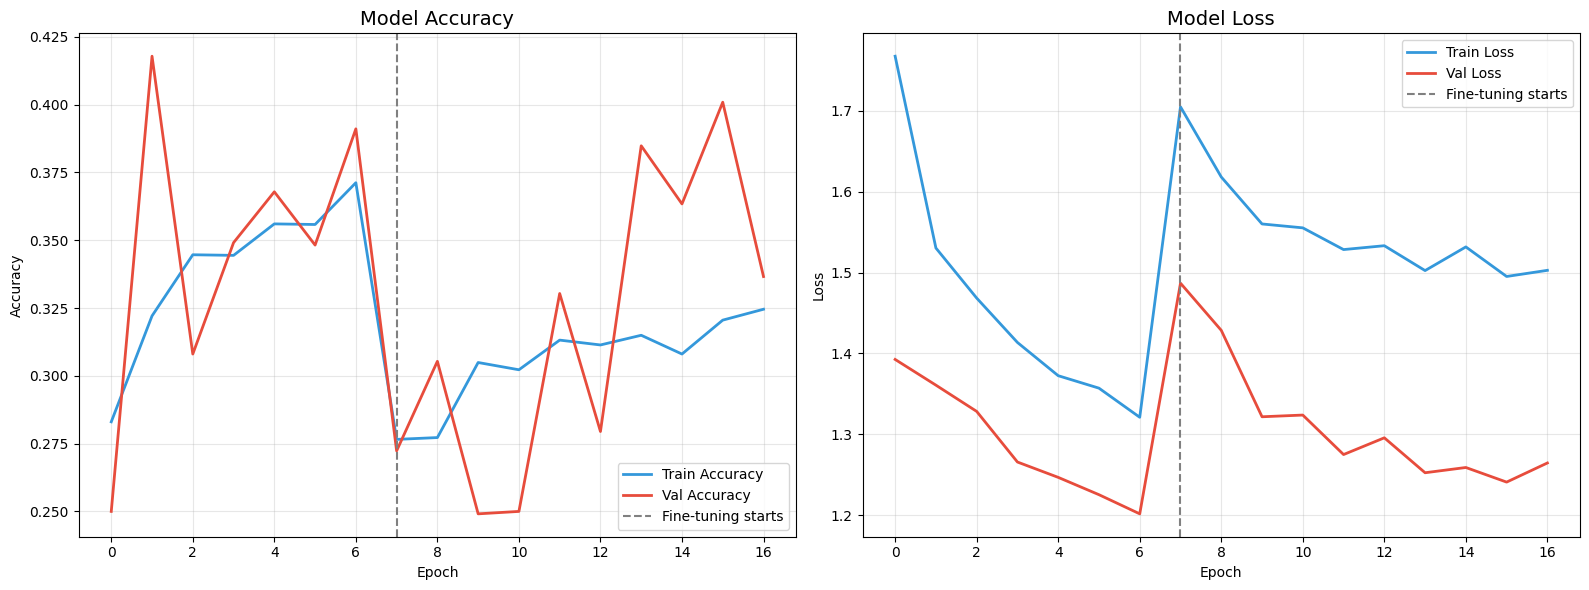

In [16]:
# --- Cell 16: Plot Training Curves (Both Phases Combined)
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history_combined = combine_histories(history_phase1, history_phase2)
phase1_epochs = len(history_phase1.history['accuracy'])
total_epochs = len(history_combined['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history_combined['accuracy'], label='Train Accuracy', color='#3498db', linewidth=2)
axes[0].plot(history_combined['val_accuracy'], label='Val Accuracy', color='#e74c3c', linewidth=2)
axes[0].axvline(x=phase1_epochs, color='gray', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_combined['loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(history_combined['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2)
axes[1].axvline(x=phase1_epochs, color='gray', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# --- Cell 17: Evaluate on Test Set
print("Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Evaluating on test set...
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.3650 - loss: 1.2930

Test Loss: 1.2930
Test Accuracy: 0.3650 (36.50%)
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma     0.0000    0.0000    0.0000       400
  meningioma     0.2551    0.4075    0.3138       400
     notumor     0.4116    0.8500    0.5546       400
   pituitary     0.6000    0.2025    0.3028       400

    accuracy                         0.3650      1600
   macro avg     0.3167    0.3650    0.2928      1600
weighted avg     0.3167    0.3650    0.2928      1600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


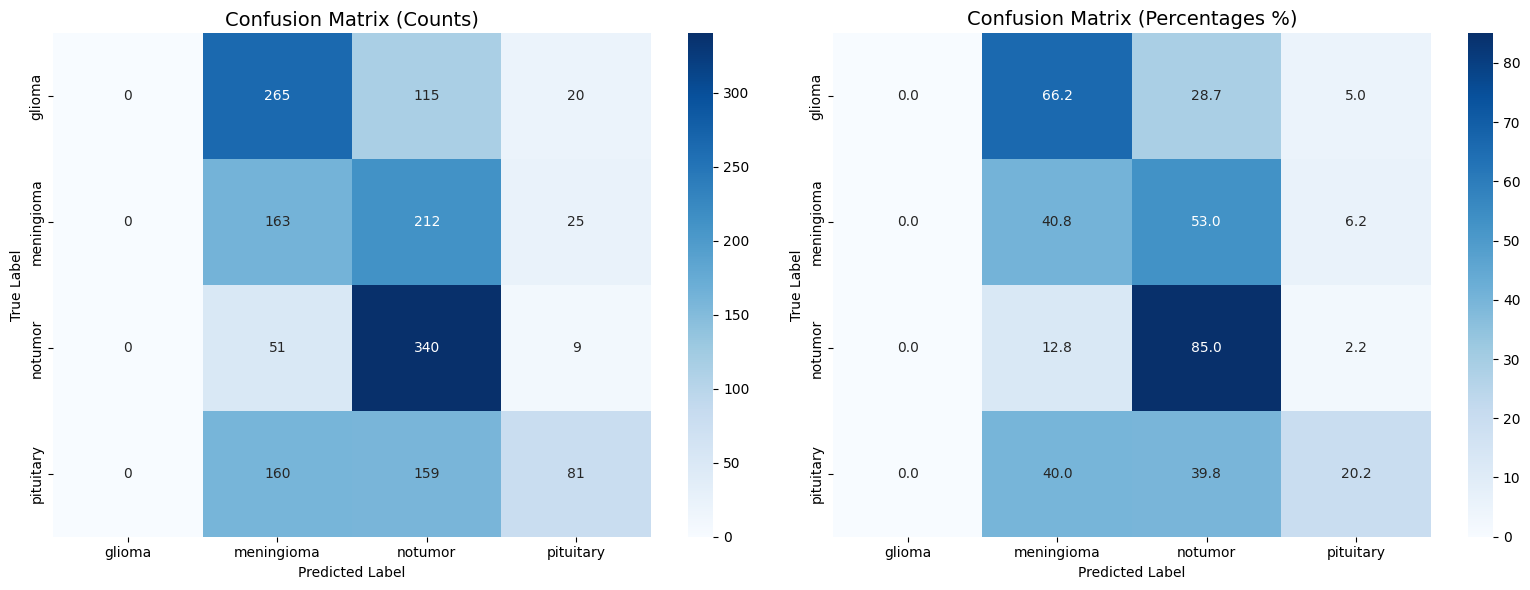

In [18]:
# --- Cell 18: Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentages %)', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
# --- Cell 19: Grad-CAM Implementation

_base = None
for _layer in model.layers:
    if isinstance(_layer, tf.keras.Model):
        _base = _layer
        break

_last_conv_layer = None
for _layer in reversed(_base.layers):
    if isinstance(_layer, tf.keras.layers.Conv2D):
        _last_conv_layer = _layer
        break

print(f"Base model: {_base.name}")
print(f"Last conv layer: {_last_conv_layer.name}")

_inp = model.input
_conv_output = _base.get_layer(_last_conv_layer.name).output
_base_grad = tf.keras.Model(inputs=_base.input, outputs=[_conv_output, _base.output])
_conv_out, _base_out = _base_grad(_inp)

_head_x = _base_out
for _hlayer in model.layers:
    if _hlayer == model.layers[0] or isinstance(_hlayer, tf.keras.Model):
        continue
    _head_x = _hlayer(_head_x)

grad_cam_model = tf.keras.Model(inputs=_inp, outputs=[_conv_out, _head_x])
print("Grad-CAM model built successfully!")

def make_gradcam_heatmap(img_array, grad_model):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(tf.cast(img_array, tf.float32))
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index.numpy(), predictions.numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return img, heatmap_colored, superimposed

print("Grad-CAM functions ready.")


Base model: efficientnetb0
Last conv layer: top_conv
Grad-CAM model built successfully!
Grad-CAM functions ready.


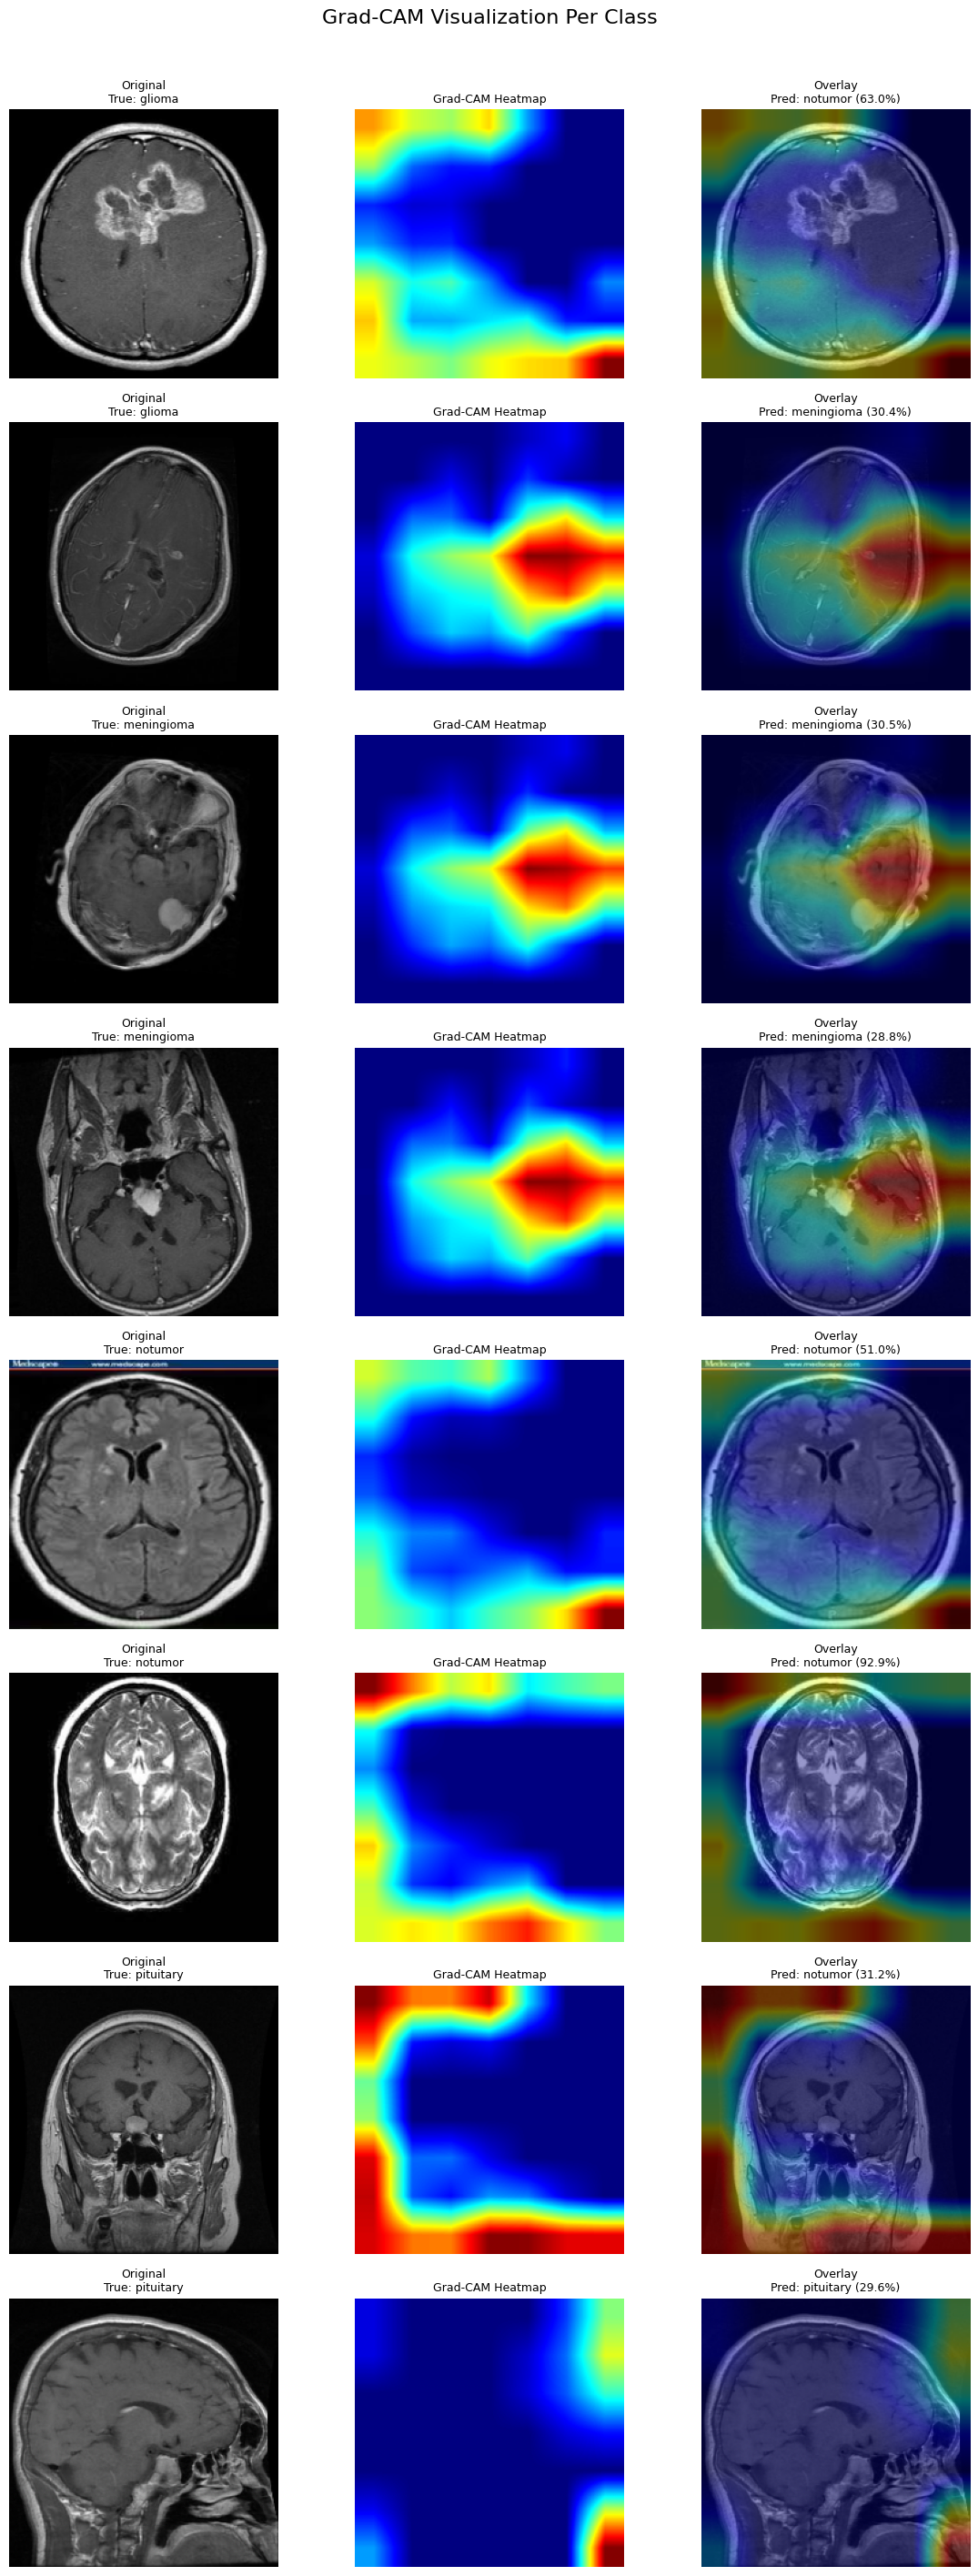

In [22]:
# --- Cell 20: Grad-CAM Visualization (2 Images Per Class)
fig, axes = plt.subplots(8, 3, figsize=(12, 28))
row = 0

for cls in classes:
    cls_path = os.path.join(TEST_DIR, cls)
    sample_images = sorted(os.listdir(cls_path))[:2]

    for img_name in sample_images:
        img_path = os.path.join(cls_path, img_name)

        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = img_array / 255.0
        img_array_expanded = np.expand_dims(img_array, axis=0)

        heatmap, pred_idx, probs = make_gradcam_heatmap(img_array_expanded, grad_cam_model)
        original, heatmap_colored, superimposed = overlay_gradcam(img_path, heatmap)

        pred_class = class_names[pred_idx]
        confidence = probs[0][pred_idx] * 100

        axes[row][0].imshow(original)
        axes[row][0].set_title(f'Original\nTrue: {cls}', fontsize=9)
        axes[row][0].axis('off')

        axes[row][1].imshow(heatmap_colored)
        axes[row][1].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[row][1].axis('off')

        axes[row][2].imshow(superimposed)
        axes[row][2].set_title(f'Overlay\nPred: {pred_class} ({confidence:.1f}%)', fontsize=9)
        axes[row][2].axis('off')

        row += 1

plt.suptitle('Grad-CAM Visualization Per Class', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
# --- Cell 21: Save the Model
model.save('brain_tumor_classifier.keras')
print("✅ Model saved as brain_tumor_classifier.keras")

model.save('brain_tumor_classifier.h5')
print("✅ Model saved as brain_tumor_classifier.h5")

phase1_epochs = len(history_phase1.history['accuracy'])
phase2_epochs = len(history_phase2.history['accuracy'])

print("\n" + "=" * 50)
print("       FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"  Test Accuracy : {test_accuracy*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Classes       : {class_names}")
print(f"  Model         : EfficientNetB0 + Transfer Learning + Fine-tuning")
print(f"  Input Size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Total Epochs  : Phase 1 ({phase1_epochs}) + Phase 2 ({phase2_epochs})")
print("=" * 50)
print("🧠 Brain Tumor Classification Complete!")


✅ Model saved as brain_tumor_classifier.keras
✅ Model saved as brain_tumor_classifier.h5

       FINAL RESULTS SUMMARY
  Test Accuracy : 36.50%
  Test Loss     : 1.2930
  Classes       : ['glioma', 'meningioma', 'notumor', 'pituitary']
  Model         : EfficientNetB0 + Transfer Learning + Fine-tuning
  Input Size    : 224x224
  Total Epochs  : Phase 1 (7) + Phase 2 (10)
🧠 Brain Tumor Classification Complete!


In [24]:
from google.colab import files

# Download saved models
files.download('brain_tumor_classifier.keras')
files.download('brain_tumor_classifier.h5')

# Download all plots
files.download('class_distribution.png')
files.download('sample_images.png')
files.download('training_curves.png')
files.download('confusion_matrix.png')
files.download('gradcam_results.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>